### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [26]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df                   # df di default è un pandas data frame
# df.colums          # ci da i nomi di tutte le colonne

# Step 1:
paesi_per_litri_alcolpuro = df.sort_values(by = "total_litres_of_pure_alcohol", ascending = False).head(10)
# df.sort_values("total_litres_of_pure_alcohol")   ordina il dataframe in base alla colonna indicata
# ascending = False                                ordina dal più alto al più basso
# .head(10)                                        prende solo le prime 10 righe dopo l'ordinamento
print("Primi 10 paesi per consumo di alcol puro:\n", paesi_per_litri_alcolpuro)

Primi 10 paesi per consumo di alcol puro:
                 country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
45       Czech Republic            361              170            134   
61               France            127              151            370   
141  Russian Federation            247              326             73   
81              Ireland            313              118            165   
155            Slovakia            196              293            116   
99           Luxembourg            236              133            271   

     total_litres_of_pure_alcohol  
15                           14.4  
98                           12.9  
3                            12.4 

In [20]:
# Step 2:
df["beer_servings"]                            # ritorna gli indici e i valori in una tabella
df["beer_servings"].values                     # riorna un array che contiene tutti i valori, si perdono gli indici
media_birra = df["beer_servings"].mean()
print("Media birra: ", media_birra)            # uguale per vino e distillati

#oppure:
import numpy as np
media_birra2 = np.mean(df["beer_servings"].values)
print("Media birra: ", media_birra2)

media_vino = np.mean(df["wine_servings"].values)
print("Media vino: ", media_vino)

media_distillati = np.mean(df["spirit_servings"].values)
print("Media distillati: ", media_distillati)

Media birra:  106.16062176165804
Media birra:  106.16062176165804
Media vino:  49.45077720207254
Media distillati:  80.99481865284974


In [21]:
# Step 3:
df["beer_servings"] + df["wine_servings"]      # sotto fa df["beer_servings"].values + df["wine_servings"].values

df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]
nuova_colonna = (df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3   # dytype è float
df["alcohol_index"] = nuova_colonna
df

# oppure:
df[["beer_servings", "wine_servings", "spirit_servings"]]                           # così ho una matrice
df[["beer_servings", "wine_servings", "spirit_servings"]].mean()                    # così fa la media per colonne
df[["beer_servings", "wine_servings", "spirit_servings"]].values.mean()             # così fa la media di tutta la matrice 
media = df[["beer_servings", "wine_servings", "spirit_servings"]].mean(axis = 1)    # così fa la media per righe
print("Media: ", media)
df

Media:  0        0.000000
1       91.666667
2       13.000000
3      231.666667
4      106.333333
          ...    
188    145.333333
189     38.000000
190      2.000000
191     18.333333
192     28.666667
Length: 193, dtype: float64


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
0,Afghanistan,0,0,0,0.0,0.000000
1,Albania,89,132,54,4.9,91.666667
2,Algeria,25,0,14,0.7,13.000000
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,145.333333
189,Vietnam,111,2,1,2.0,38.000000
190,Yemen,6,0,0,0.1,2.000000
191,Zambia,32,19,4,2.5,18.333333


In [22]:
# Step 4:  qui c'è qualcosa di sbagliato
max_alcohol_index1 = df.sort_values(by = 'alcohol_index', ascending = False).head(1)
print("Paese con alcohol index più alto (1):\n", max_alcohol_index1)

# oppure: questi due sono equivalenti
max_alcohol_index2 = df[df['alcohol_index'] == df['alcohol_index'].max()]
print("Paese con alcohol index più alto (2):\n", max_alcohol_index2)

Paese con alcohol index più alto (1):
    country  beer_servings  spirit_servings  wine_servings  \
3  Andorra            245              138            312   

   total_litres_of_pure_alcohol  alcohol_index  
3                          12.4     231.666667  
Paese con alcohol index più alto (2):
    country  beer_servings  spirit_servings  wine_servings  \
3  Andorra            245              138            312   

   total_litres_of_pure_alcohol  alcohol_index  
3                          12.4     231.666667  


In [23]:
# Step 5:
paesi_piu_100_birre = df[df["beer_servings"] > 100]
print("Paesi che consumano più di 100 birre:\n", paesi_piu_100_birre)

Paesi che consumano più di 100 birre:
                country  beer_servings  spirit_servings  wine_servings  \
3              Andorra            245              138            312   
4               Angola            217               57             45   
5    Antigua & Barbuda            102              128             45   
6            Argentina            193               25            221   
8            Australia            261               72            212   
..                 ...            ...              ...            ...   
182     United Kingdom            219              126            195   
184                USA            249              158             84   
185            Uruguay            115               35            220   
188          Venezuela            333              100              3   
189            Vietnam            111                2              1   

     total_litres_of_pure_alcohol  alcohol_index  
3                            12.4

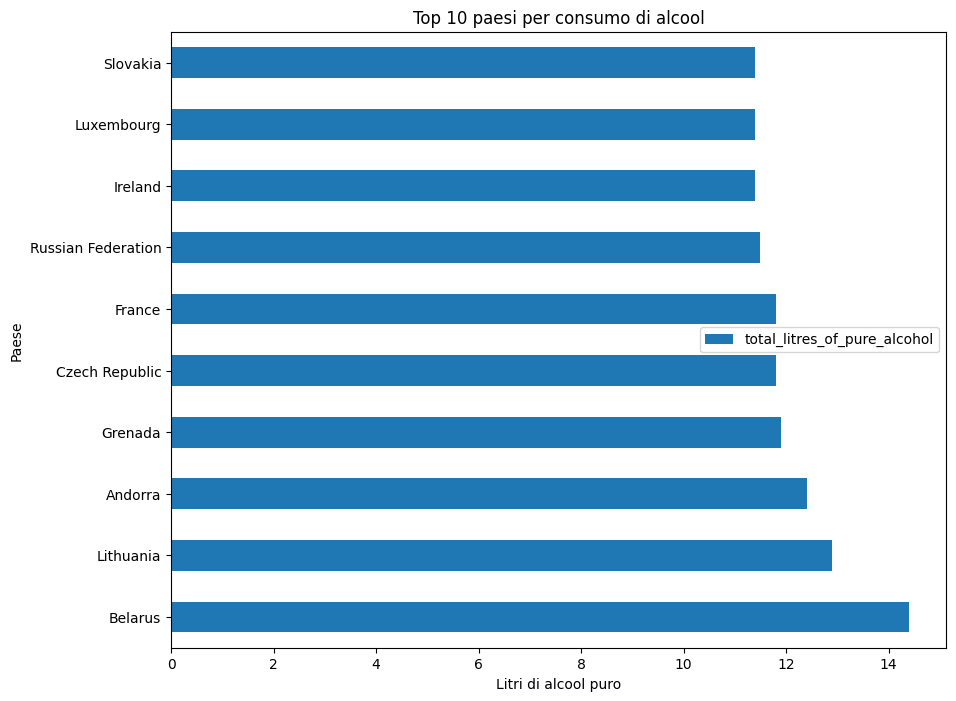

In [48]:
# Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)
# il grafico si fa cin matplotlib

import pandas as pd
import matplotlib.pyplot as plt

top10 = df.nlargest(10, "total_litres_of_pure_alcohol")                                # metodo che restituisce le 10 righe con i valori più alti

# top10.plot.bar(x = "country", y = "total_litres_of_pure_alcohol")                    # grafico senza modifiche
# plt.show()

# top10.plot.barh(x = "country", y = "total_litres_of_pure_alcohol")                   # .barh inverte asse x e y
top10.plot.barh(x = "country", y = "total_litres_of_pure_alcohol", figsize = (10, 8))  # figsize allarga il grafico
# plt.xticks(rotation = 45, ha = "right")                                              # rotatio inclina il testo, ha allinea a destra
plt.title("Top 10 paesi per consumo di alcool")
plt.xlabel("Litri di alcool puro")
plt.ylabel("Paese")
plt.show()

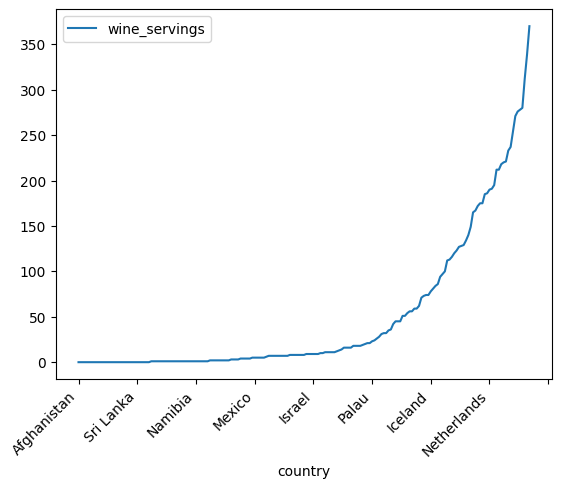

In [51]:
# Crea un line plot con wine_servings ordinato per paese (usa sort_values)

wine_servings = df.sort_values(by = "wine_servings")
# print("wine_servings:\n", wine_servings)

wine_servings.plot.line(x = "country", y= "wine_servings")
plt.xticks(rotation = 45, ha="right")                       # rotatio inclina il testo, ha allinea a destra
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [60]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Step 1:
nr_offerte = df['job_country'].value_counts()                   # conta le offerte di lavoro per ogni paese
media = df.groupby("job_country")["salary_year_avg"].mean()     # prima filtri per i paesi poi fai la media dei salari per paese
print("Media dei salari annuali:\n", media)
df

Media dei salari annuali:
 job_country
Afghanistan              NaN
Albania         79472.500000
Algeria         44550.000000
Angola                   NaN
Argentina      105212.343750
                   ...      
Venezuela                NaN
Vietnam         90927.236364
Yemen                    NaN
Zambia          90670.000000
Zimbabwe        67056.666667
Name: salary_year_avg, Length: 160, dtype: float64


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [59]:
# Step 2:
nr_offerte_per_paese = df["job_country"].value_counts(ascending = True)    # ascending = True dal più piccolo al più grande
print("Numero offerte di lavoro per paese:\n", nr_offerte_per_paese)

# oppure, però così non sono in ordine decrescente:
nr_offerte_per_paese_no_ordine = df.groupby("job_country")["job_country"].count()
print("Numero offerte di lavoro per paese non in ordine:\n", nr_offerte_per_paese_no_ordine)

Numero offerte di lavoro per paese:
 job_country
Maldives               2
Lesotho                3
Mauritania             3
Bhutan                 3
Guinea                 4
                   ...  
Germany            27694
France             39922
United Kingdom     40375
India              51088
United States     206292
Name: count, Length: 160, dtype: int64
Numero offerte di lavoro per paese non in ordine:
 job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Name: job_country, Length: 160, dtype: int64


In [64]:
# Step 3:
# così ho lo stipendio minimo e massimi mensile per ogni paese
stipendio_medio_min_per_mese = df.groupby("job_country")["salary_year_avg"].min()
stipendio_medio_max_per_mese = df.groupby("job_country")["salary_year_avg"].max()
print("Stipendi minimi mensili:\n", stipendio_medio_min_per_mese)
print("Stipendi massimi mensili:\n", stipendio_medio_max_per_mese)

# così ho lo stipendio minimo e massimi mensile tra tutti i paesi
stipendio_min = df["salary_year_avg"].min()
stipendio_max = df["salary_year_avg"].max()

print("Stipendio minimo:\n", stipendio_min)
print("Stipendio massimo:\n", stipendio_max)

Stipendi minimi mensili:
 job_country
Afghanistan        NaN
Albania        43200.0
Algeria        44100.0
Angola             NaN
Argentina      45000.0
                ...   
Venezuela          NaN
Vietnam        28000.0
Yemen              NaN
Zambia         90670.0
Zimbabwe       47500.0
Name: salary_year_avg, Length: 160, dtype: float64
Stipendi massimi mensili:
 job_country
Afghanistan         NaN
Albania        157500.0
Algeria         45000.0
Angola              NaN
Argentina      222000.0
                 ...   
Venezuela           NaN
Vietnam        200000.0
Yemen               NaN
Zambia          90670.0
Zimbabwe        90670.0
Name: salary_year_avg, Length: 160, dtype: float64
Stipendio minimo:
 15000.0
Stipendio massimo:
 960000.0


Stipendio medio per job title:
 job_title_short
Business Analyst              91082.612833
Data Analyst                  93841.907854
Cloud Engineer               111268.453846
Software Engineer            113393.760054
Senior Data Analyst          113911.363665
Machine Learning Engineer    126774.315972
Data Engineer                130125.604250
Data Scientist               135988.837171
Senior Data Engineer         145840.611624
Senior Data Scientist        154206.292996
Name: salary_year_avg, dtype: float64


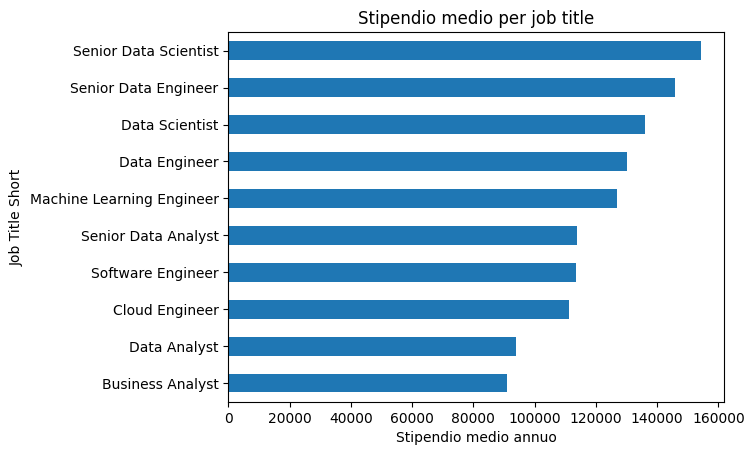

In [74]:
# Rappresenta graficamente lo stipendio medio (salary_year_avg) per job_title_short usando un grafico a barre orizzontali. 
# Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

import matplotlib.pyplot as plt

stipendio_medio_per_job_title = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending = True)
print("Stipendio medio per job title:\n", stipendio_medio_per_job_title)

stipendio_medio_per_job_title.plot(kind = 'barh')
plt.xlabel("Stipendio medio annuo")
plt.ylabel("Job Title Short")
plt.title("Stipendio medio per job title")
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [75]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [78]:
# Step 1:
media = df.groupby("day")["total_bill"].mean()  # così ho la media solo per quella colonna
print("Conto medio: ", media)

Conto medio:  day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64


In [79]:
# Step 2:
conteggio_tot = df["total_bill"].count()
print("Numero totale di osservazioni: ", conteggio_tot)

conteggio = df.groupby("day")["total_bill"].count()       # così ho il conteggio per quella colonna
print("Conteggio per giorno: ", conteggio)

Numero totale di osservazioni:  244
Conteggio per giorno:  day
Fri     19
Sat     87
Sun     76
Thur    62
Name: total_bill, dtype: int64


In [80]:
# Step 3:
min = df["total_bill"].min()
max = df["total_bill"].max()
print("Valore minimo del conto: ", min)
print("Valore massimo del conto: ", max)

Valore minimo del conto:  3.07
Valore massimo del conto:  50.81


In [82]:
# Step 4:
nuova_colonna = (df["total_bill"] / df["size"])
df["conto_per_persona"] = nuova_colonna
df

,total_bill,tip,sex,smoker,day,time,size,conto_per_persona
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.676667
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.590000
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.335000
242,17.82,1.75,Male,No,Sat,Dinner,2,8.910000


In [86]:
# Step 5:
giorno_max = df.groupby("day")["total_bill"].mean().idxmax()   # idxmax() restituisce l'indice, in questo caso il giorno
print("Giorno con il conto medio più alto: ", giorno_max)

Giorno con il conto medio più alto:  Sun


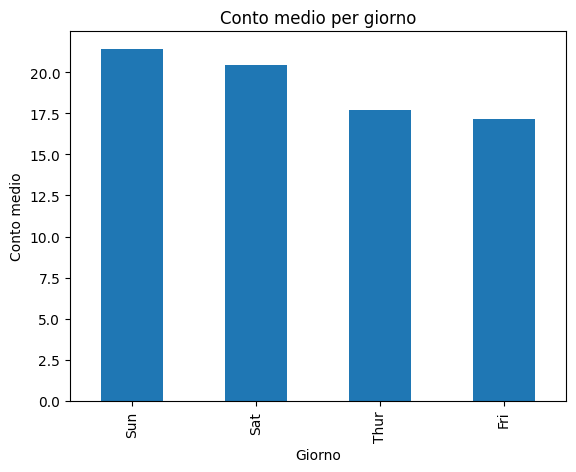

In [93]:
# Rappresenta graficamente il conto medio (total_bill) per giorno usando un grafico a barre.
# Ordina i dati dal valore più alto al più basso.
# Aggiungi titolo ed etichette agli assi.

import matplotlib.pyplot as plt

conto_medio = df.groupby("day")["total_bill"].mean().sort_values(ascending = False)
conto_medio.plot(kind = 'bar')
plt.title("Conto medio per giorno")
plt.xlabel("Giorno")
plt.ylabel("Conto medio")
plt.show()